In [52]:
import graph_tool.topology as gtt
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
import graph_tool as gt
import pandas as pd
import numpy as np
import os

In [2]:
gdfs = {}

Load the administrative boundaries.

In [61]:
gdfs['adm1'] = gpd.read_file('../../data/gadm41_SOM_1.json.zip')

In [62]:
gdfs['adm2'] = gpd.read_file('../../data/gadm41_SOM_2.json.zip')

Load components of the road network (nodes, edges).

In [74]:
%%time
gdfs['nodes'] = gpd.read_file('/data/big/fmalveiro/complexity72/road_network_elements.zip!somalia-250905-nodes.geojson')

CPU times: user 36.1 s, sys: 1.18 s, total: 37.3 s
Wall time: 36.9 s


In [75]:
%%time
gdfs['edges'] = gpd.read_file('/data/big/fmalveiro/complexity72/road_network_elements.zip!somalia-250905-edges.geojson')

CPU times: user 1min 7s, sys: 6.24 s, total: 1min 14s
Wall time: 2min 4s


<Axes: >

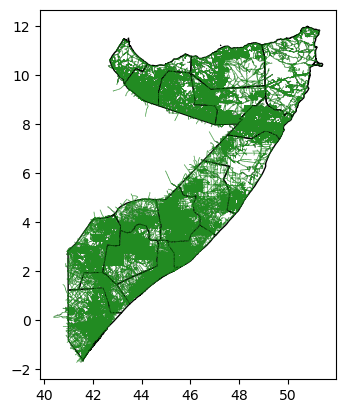

In [13]:
%%time
fig, ax = plt.subplots(1)

gdfs['adm'].boundary.plot(ax=ax, color='k', linewidth=1)
gdfs['edges'].plot(ax=ax, color='forestgreen', linewidth=.5)

ax.set_title(f"{gdfs['edges'].shape[0]} edges")

Load the road network graph.

In [76]:
graph = gt.load_graph('/data/big/fmalveiro/complexity72/somalia-road_network_graph.gt.gz')

Compute graph components.

In [77]:
comps, hist = gtt.label_components(graph, directed=False)

In [78]:
components = pd.Series(comps)
histogram = pd.Series(hist)

How many components are there?

Text(0.5, 1.0, '1179 components')

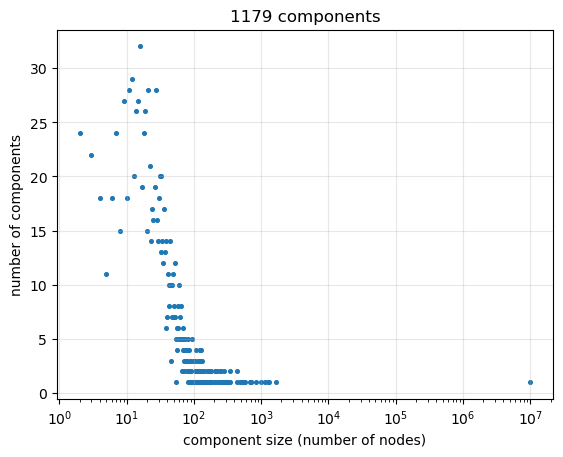

In [79]:
vector = histogram.value_counts(dropna=False).sort_index()
x = vector.index
y = vector.to_numpy()

fig, ax = plt.subplots(1)

ax.set_xlabel('component size (number of nodes)')
ax.set_ylabel('number of components')

ax.set_xscale('log')

ax.scatter(x, y, s=7)

ax.grid('on', alpha=.3)

ax.set_title(f"{histogram.size} components")

For each node, identify the size of the component to which it belongs.

In [17]:
%%time
size_comp = components.map(lambda x: histogram.loc[x])

In [ ]:
cmap = plt.get_cmap('viridis')
norm = mpl.colors.LogNorm(vmin=1, vmax=histogram.max())

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

colours = size_comp.apply(lambda x: cmap(norm(x)))

Plot the nodes of the road network coloured by the size of the component to which they belong. Two purposes:
- check whether LCC spans the whole country;
- highlight small-sized components.

CPU times: user 1h 39min 36s, sys: 3min 32s, total: 1h 43min 9s
Wall time: 1h 40min 26s


<Axes: >

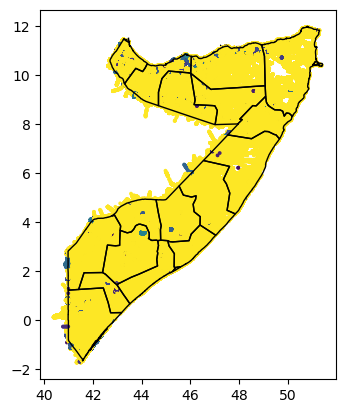

In [21]:
%%time
fig, ax = plt.subplots(1)

gdfs['adm'].boundary.plot(ax=ax, color='k', linewidth=1)
gdfs['nodes'].plot(ax=ax, color=colours, markersize=3)

ax.set_title(f"{gdfs['nodes'].shape[0]} nodes")

fig.colorbar(sm, label='component size')

Identify the label attributed to the LCC.

In [27]:
lcc_idx = histogram.argmax()
lcc_idx

0

Get all nodes that belong to the LCC.

In [28]:
lcc = gdfs['nodes'][components == lcc_idx]

CPU times: user 6min 26s, sys: 9.86 s, total: 6min 36s
Wall time: 6min 35s


Text(0.5, 1.0, 'LCC: 10074388 / 10141651 nodes (99.34)%')

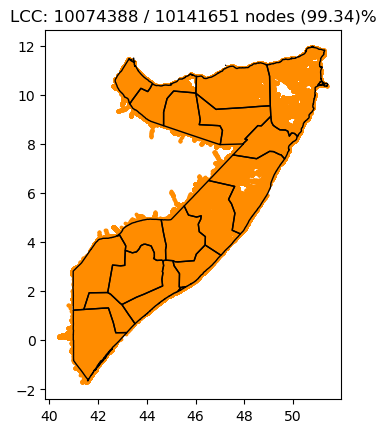

In [31]:
%%time
fig, ax = plt.subplots(1)

gdfs['adm'].boundary.plot(ax=ax, color='k', linewidth=1)
lcc.plot(ax=ax, color='darkorange', markersize=3)

ax.set_title(f"LCC: {lcc.shape[0]} / {gdfs['nodes'].shape[0]} nodes ({100*(lcc.shape[0] / gdfs['nodes'].shape[0]):.2f}%)")

Project the geographical data to a projected coordinate system using metres as a unit 
- more adequate to compute distances.

In [34]:
%%time
proj_gdfs = {key: value.to_crs('epsg:20539') for key, value in gdfs.items()}

CPU times: user 44 s, sys: 13.8 s, total: 57.9 s
Wall time: 58.9 s


Find the centroid of each admin unit.

In [35]:
for key in (1,2):
    proj_gdfs[f"adm{key}"]['centroid'] = proj_gdfs[f"adm{key}"].centroid 

In [36]:
proj_lcc = proj_gdfs['nodes'][components == lcc_idx]

Find the nodes of the LCC that are nearest to each admin unit centroid.

In [48]:
nearest = {}

In [49]:
%%time
for key in (1,2):
    nearest[f"adm{key}"] = proj_gdfs[f"adm{key}"][['centroid']].set_geometry('centroid').sjoin_nearest(proj_lcc[['geometry']], distance_col='distance')

CPU times: user 11.6 s, sys: 4.22 s, total: 15.8 s
Wall time: 15.8 s


Text(0.5, 0.98, 'Distance from centroid of admin areas to closest node in LCC')

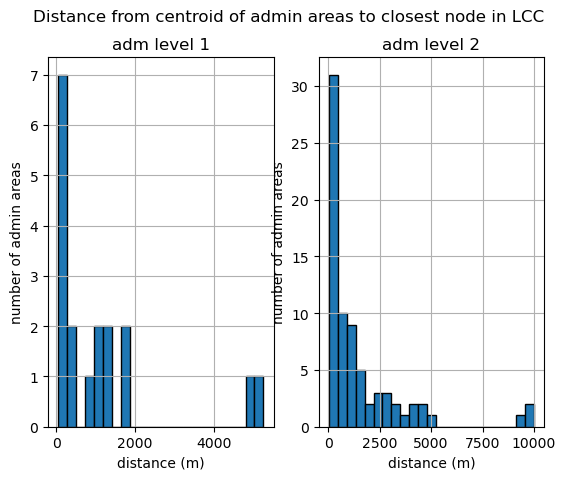

In [55]:
k = 23

fig, axs = plt.subplots(nrows=1, ncols=2)

for key, ax in zip((1,2), axs.ravel()):
    y = nearest[f"adm{key}"]['distance']

    hist, bins = np.histogram(y, bins=k)
    ax.bar(bins[:-1], hist, width=np.diff(bins), align='edge', edgecolor='k')

    ax.set_xlabel('distance (m)')
    ax.set_ylabel('number of admin areas')
    
    ax.grid('on')
    ax.set_title(f"adm level {key}")

fig.suptitle(f"Distance from centroid of admin areas to closest node in LCC")

Identify the admin units that are the most distant to the LCC.

In [63]:
furthest = nearest['adm2']['distance'].sort_values(ascending=False)
furthest

49    9997.993520
3     9586.081560
51    9373.232219
14    5165.507863
47    4674.035897
         ...     
56      69.705709
58      61.124752
48      41.067921
40      39.593340
72      37.377052
Name: distance, Length: 74, dtype: float64

The top 5 is:

In [64]:
gdfs['adm2']['NAME_2'].loc[furthest.index[:5]]

49        Badhan
3         Zeylac
51    Ceerigaabo
14       Qandala
47           Eyl
Name: NAME_2, dtype: object